In [2]:
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

df = pd.read_csv("/Users/ilyaklimasin/Downloads/archive-4/application_train.csv")
print(df.shape)

(307511, 122)


In [3]:
x = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE,)
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)

print("Train: ", x_train.shape)
print("Validation: ", x_valid.shape)
print("Test: ", x_test.shape)
print("Train rate: ", y_train.mean())
print("Validation rate: ", y_valid.mean())
print("Test rate: ", y_test.mean())

Train:  (184506, 120)
Validation:  (61502, 120)
Test:  (61503, 120)
Train rate:  0.08072908198107379
Validation rate:  0.08072908198107379
Test rate:  0.08072776937710356


In [ ]:
def replace_employed_anomaly(data):
    result = data.copy()
    result["DAYS_EMPLOYED"] = result["DAYS_EMPLOYED"].replace(365243, np.nan)
    return result

x_train = replace_employed_anomaly(x_train)
x_valid = replace_employed_anomaly(x_valid)
x_test = replace_employed_anomaly(x_test)

In [8]:
categorical_columns = x_train.select_dtypes(include="object").columns.tolist()
print("Categorical features: ", len(categorical_columns))


Categorical features:  16


In [9]:
for column in categorical_columns:
    x_train[column] = x_train[column].fillna("Missing").astype(str)
    x_valid[column] = x_valid[column].fillna("Missing").astype(str)
    x_test[column] = x_test[column].fillna("Missing").astype(str)


In [11]:
catboost_model = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=6, loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE, verbose=100, allow_writing_files=False,)
catboost_model.fit(x_train, y_train, cat_features=categorical_columns, eval_set=(x_valid, y_valid), early_stopping_rounds=100,)
print("The best iteration: ", catboost_model.get_best_iteration())
print("The best result: ", catboost_model.get_best_score())

0:	test: 0.6719522	best: 0.6719522 (0)	total: 258ms	remaining: 4m 18s
100:	test: 0.7471102	best: 0.7471102 (100)	total: 30.4s	remaining: 4m 30s
200:	test: 0.7534139	best: 0.7534139 (200)	total: 1m 9s	remaining: 4m 34s
300:	test: 0.7562615	best: 0.7562615 (300)	total: 1m 52s	remaining: 4m 21s
400:	test: 0.7575665	best: 0.7575665 (400)	total: 2m 22s	remaining: 3m 33s
500:	test: 0.7583827	best: 0.7583827 (500)	total: 2m 53s	remaining: 2m 52s
600:	test: 0.7589672	best: 0.7589672 (600)	total: 3m 23s	remaining: 2m 15s
700:	test: 0.7594096	best: 0.7594923 (675)	total: 3m 52s	remaining: 1m 39s
800:	test: 0.7596318	best: 0.7596318 (800)	total: 4m 22s	remaining: 1m 5s
900:	test: 0.7600182	best: 0.7600202 (893)	total: 4m 51s	remaining: 32s
999:	test: 0.7600710	best: 0.7602786 (953)	total: 5m 20s	remaining: 0us

bestTest = 0.7602786265
bestIteration = 953

Shrink model to first 954 iterations.
The best iteration:  953
The best result:  {'learn': {'Logloss': 0.2313956300853838}, 'validation': {'Log

In [13]:
catboost_probabilities = catboost_model.predict_proba(x_valid)[:, 1]

In [14]:
def calculate_metrics(y_true, probabilities,):
    return {
        "roc_auc": roc_auc_score(y_true, probabilities,),
        "pr_auc": average_precision_score(y_true, probabilities,),
        "brier_score": brier_score_loss(y_true, probabilities,),
    }


catboost_metrics = calculate_metrics(y_valid, catboost_probabilities)
catboost_metrics

{'roc_auc': np.float64(0.760278626544789),
 'pr_auc': np.float64(0.24843807359667847),
 'brier_score': np.float64(0.06763254136712962)}

In [16]:
comparison = pd.DataFrame([
    {
        "model": "Dummy",
        "roc_auc": 0.5000,
        "pr_auc": 0.08007,
        "brier_score":0.0742,
    },
    {
        "model": "Logistic Regression",
        "roc_auc": 0.7130,
        "pr_auc": 0.2139,
        "brier_score": 0.0696,
    },
    {
        "model":"CatBoost",
        **catboost_metrics
    }
])
comparison.round(4)

,model,roc_auc,pr_auc,brier_score
0,Dummy,0.5000,0.0801,0.0742
1,Logistic Regression,0.7130,0.2139,0.0696
2,CatBoost,0.7603,0.2484,0.0676


In [19]:
logistic_roc_auc = 0.7130
logistic_pr_auc = 0.2139
logistic_brier = 0.0696

roc_improvement = catboost_metrics["roc_auc"] - logistic_roc_auc
pr_improvement = catboost_metrics["pr_auc"] - logistic_pr_auc
brier_improvement = catboost_metrics["brier_score"] - logistic_brier
print(f"Changes ROC-AUC: " f"{roc_improvement:+.4f}")
print(f"Changes PR-AUC: " f"{pr_improvement:+.4f}")
print(f"Changes Brier score: " f"{brier_improvement:+.4f}")

Changes ROC-AUC: +0.0473
Changes PR-AUC: +0.0345
Changes Brier score: -0.0020


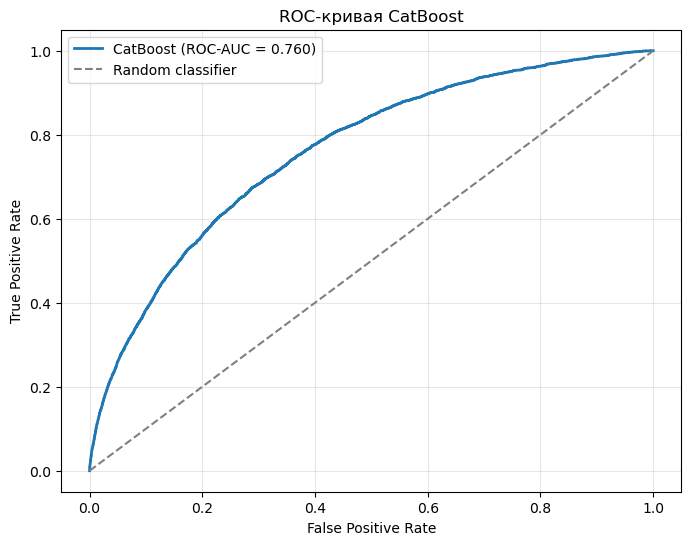

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

catboost_probabilities = catboost_model.predict_proba(x_valid)[:, 1]
catboost_auc = roc_auc_score(
    y_valid,
    catboost_probabilities
)
catboost_fpr, catboost_tpr, _ = roc_curve(
    y_valid,
    catboost_probabilities
)
plt.figure(figsize=(8, 6))

plt.plot(
    catboost_fpr,
    catboost_tpr,
    linewidth=2,
    label=f"CatBoost (ROC-AUC = {catboost_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

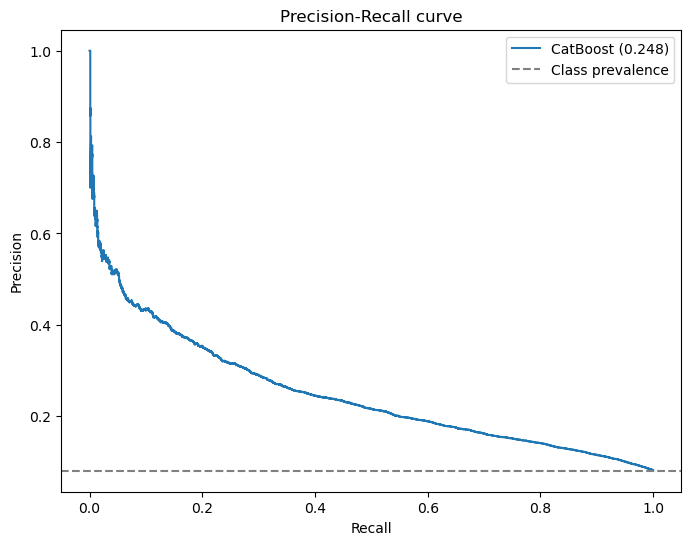

In [32]:
from sklearn.metrics import precision_recall_curve
precision, recall, _ = precision_recall_curve(y_valid, catboost_probabilities)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=(f"CatBoost " f"({catboost_metrics['pr_auc']:.3f})"),)
plt.axhline(y=y_valid.mean(), linestyle="--", color="grey", label="Class prevalence",)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.show()

In [33]:
feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": catboost_model.get_feature_importance(),
})
feature_importance = feature_importance.sort_values("importance", ascending=False,)
feature_importance.head(20)


,feature,importance
41,EXT_SOURCE_3,16.963382
40,EXT_SOURCE_2,13.832047
39,EXT_SOURCE_1,6.456912
6,AMT_CREDIT,4.782259
8,AMT_GOODS_PRICE,4.669050
15,DAYS_BIRTH,4.651860
16,DAYS_EMPLOYED,3.860667
7,AMT_ANNUITY,3.624595
18,DAYS_ID_PUBLISH,2.217119
17,DAYS_REGISTRATION,2.104862


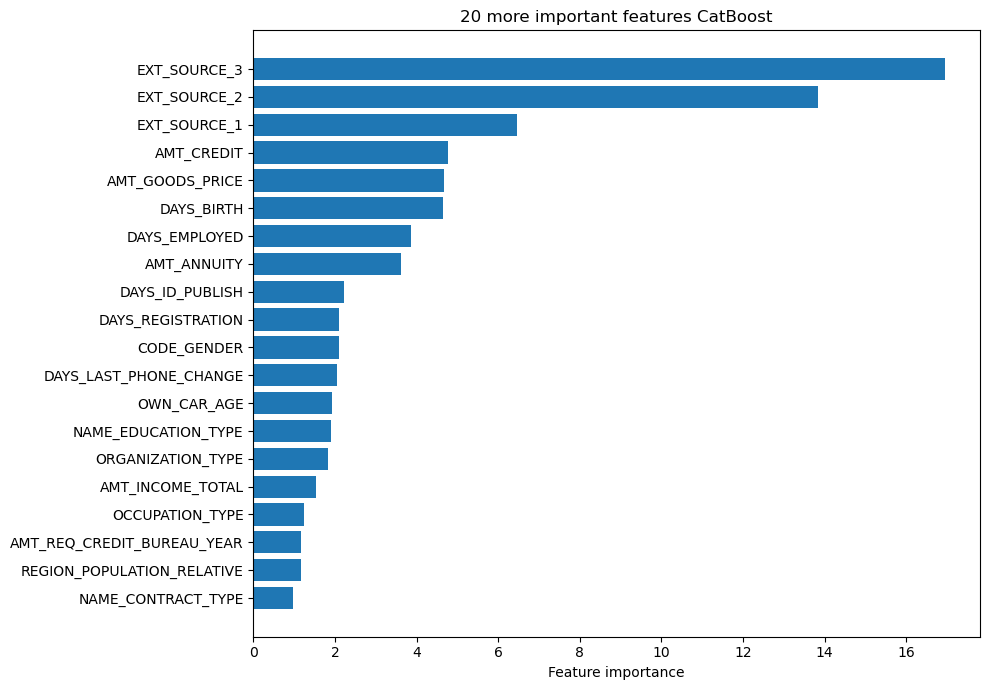

In [34]:
top_features = feature_importance.head(20).sort_values("importance")
plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["importance"],)
plt.title("20 more important features CatBoost")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [39]:
experiment_results = []
for depth in [5, 7]:
    model = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=depth, loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE, verbose=False, allow_const_label=False,)
    model.fit(
        x_train,
        y_train,
        cat_features=categorical_columns,
        eval_set=(x_valid, y_valid),
        early_stopping_rounds=100,
    )
    probabilities = model.predict_proba(x_valid)[:, 1]
    experiment_results.append({"depth": depth, "best_iteration": model.get_best_iteration(),
                               **calculate_metrics(y_valid, probabilities,),})

pd.DataFrame(experiment_results)

,depth,best_iteration,roc_auc,pr_auc,brier_score
0,5,998,0.759291,0.246353,0.067703
1,7,913,0.759747,0.247376,0.067675


## Выводы третьего этапа

1. Обучена модель CatBoost, которая обрабатывает числовые пропуски и категориальные признаки без применения One-Hot Encoding.

2. Для снижения риска переобучения использован early stopping с оценкой качества на validation-выборке. Лучшая итерация основной модели составила **[результат `catboost_model.get_best_iteration()`]**.

3. CatBoost достиг следующих результатов на validation-выборке:

   - ROC-AUC — **0.7603**;
   - PR-AUC — **0.2484**;
   - Brier score — **0.0676**.

4. CatBoost превзошёл Logistic Regression по всем выбранным метрикам:

   - ROC-AUC увеличился на **0.0473**: с 0.7130 до 0.7603;
   - PR-AUC увеличился на **0.0345**: с 0.2139 до 0.2484;
   - Brier score уменьшился на **0.0020**: с 0.0696 до 0.0676.

5. Уменьшение Brier score означает, что вероятностные прогнозы CatBoost оказались точнее прогнозов Logistic Regression. При этом окончательный вывод о калибровке вероятностей потребует отдельного анализа.

6. Наиболее важными для CatBoost признаками стали:

   - `EXT_SOURCE_3`;
   - `EXT_SOURCE_2`;
   - `EXT_SOURCE_1`;
   - `AMT_CREDIT`;
   - `AMT_GOODS_PRICE`;
   - `DAYS_BIRTH`;
   - `DAYS_EMPLOYED`;
   - `AMT_ANNUITY`.

7. Наибольшую важность получили внешние кредитные оценки `EXT_SOURCE_1`, `EXT_SOURCE_2` и `EXT_SOURCE_3`. Также модель активно использует сведения о размере кредита, стоимости приобретаемых товаров, возрасте клиента, трудовом стаже и размере аннуитетного платежа.

8. Feature importance показывает вклад признаков в прогнозы модели, но не доказывает причинно-следственную связь и не показывает направление влияния признака на вероятность дефолта.

9. В дополнительном эксперименте проверены значения `depth=5` и `depth=7`. Их ROC-AUC составил **0.7593** и **0.7597** соответственно. Оба результата немного ниже ROC-AUC основной модели с `depth=6`, равного **0.7603**, поэтому основная конфигурация была сохранена.

10. CatBoost выбран основной моделью для следующего этапа. Validation-выборка использовалась для выбора модели и параметров, а test-выборка осталась нетронутой для финальной оценки.

In [40]:
from pathlib import Path
import pandas as pd

Path("../reports").mkdir(exist_ok=True)

validation_predictions = pd.DataFrame({
    "target": y_valid.to_numpy(),
    "probability": catboost_model.predict_proba(x_valid)[:, 1]
})

validation_predictions.to_csv(
    "../reports/validation_predictions.csv",
    index=False
)

In [41]:
test_predictions = pd.DataFrame({
    "target": y_test.to_numpy(),
    "probability": catboost_model.predict_proba(x_test)[:, 1]
})

test_predictions.to_csv(
    "../reports/test_predictions.csv",
    index=False
)